# Project Overview

A Python project demonstrates my data cleaning skills with a small raw data set of 1000 rows curated from public data on GitHub. The data is similar to how clinical data is often collected - filled with inconsistency due to human errors! The end result will be a more presentable and clean dataset, along with graphs answering common stakeholders' questions. 
1. Patient volumns trend?
2. Which day-of-week is most crowded?
3. Most common dianogsis over the year
4. Did most patient received treatment?

# Dependencies

- Python 3.13.0 | pip 25.3
- numpy-2.4.1 | pandas-2.3.3 

# Key Data Cleaning Steps

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading data set and determine piorities:

In [125]:
raw_data = pd.read_csv("healthcarE_messy_data.csv", sep = ",")
raw_data

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number
0,david lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200.0,name@hospital.org,555-555-5555
1,emily davis,NaN,Male,Diabetes,NONE,"April 5, 2018",120/80,200.0,NaN,NaN
2,laura martinez,35,Other,Asthma,METFORMIN,2019.12.01,110/70,160.0,contact@domain.com,NaN
3,michael wilson,NaN,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,NaN,name@hospital.org,555-555-5555
4,david lee,NaN,Female,Asthma,NONE,2020/02/20,110/70,180.0,NaN,
...,...,...,...,...,...,...,...,...,...,...
995,mary clark,70,Other,Asthma,ALBUTEROL,03-25-2019,110/70,NaN,name@hospital.org,NaN
996,mary clark,forty,Other,NaN,LISINOPRIL,01/15/2020,NaN,160.0,NaN,123-456-7890
997,laura martinez,forty,Other,NaN,ALBUTEROL,2020/02/20,110/70,NaN,name@hospital.org,NaN
998,jane smith,25,Male,NaN,ALBUTEROL,"April 5, 2018",110/70,200.0,NaN,


In [126]:
# Identifi issue for cleaning:
for col in raw_data.columns:
    print(f"{col} : {raw_data[col].unique()}")

Patient Name : [' david lee ' ' emily davis ' ' laura martinez ' ' michael wilson '
 ' mary clark ' ' robert brown ' ' sarah johnson ' ' jane smith '
 ' john doe ' ' james taylor ']
Age : ['25' nan '35' '60' 'forty' '70']
Gender : ['Other' 'Male' 'Female']
Condition : ['Heart Disease' 'Diabetes' 'Asthma' 'Hypertension' nan]
Medication : ['METFORMIN' 'NONE' 'ALBUTEROL' 'LISINOPRIL' 'ATORVASTATIN']
Visit Date : ['01/15/2020' 'April 5, 2018' '2019.12.01' '2020/02/20' '03-25-2019']
Blood Pressure : ['140/90' '120/80' '110/70' nan '130/85']
Cholesterol : [200. 160.  nan 180. 220.]
Email : ['name@hospital.org' nan 'contact@domain.com' 'patient@example.com']
Phone Number : ['555-555-5555' nan ' ' '123-456-7890' '098-765-4321']


## GOALS AND OBJECTIVES

The above code revealed (issues -> solutions):
1. "Patient Name" have spaces beofre and after each value, names are not capitalized properly -> strip + capitalize
2. "Age" column have both number and letter value -> Correct non-numeric value
3. "Visit Date" column inconsistent format -> Standardize the format
4. Missing value are currently "Nan" or empty cell -> Missing Email value must be "NO-EMAIL@email.com";  Missing "Phone Number" value must be "Not_available"

## CLEAN UP

In [ ]:
def clean_column_name(df):
    # CLEAN UP
    # Strip in all column names:
    df.columns = df.columns.str.strip()
    return df

def missing_value(df):
    for col_name in df.columns:
        if df[col_name].dtype == "object":
            df[col_name] = df[col_name].str.strip()

    df = df.replace(r'^\s*$', np.nan, regex=True)
    return df

def formatting_specific_column(df):
    # APPLY FORMATTING AND GRAMMAR:
    if "Patient Name" in df.columns:
        df["Patient Name"] = df["Patient Name"].str.title()
    if "Age" in df.columns:
        df["Age"] = df["Age"].replace("forty", "40")
    if "Patient Name" in df.columns:
        df["Email"] = df["Email"].replace(np.nan, "NO-EMAIL@email.com")
    if "Patient Name" in df.columns:
       df["Phone Number"] = df["Phone Number"].replace(np.nan, "Not_available")
    return df

def format_date_and_number(df):
    # APPLY DATA TYPE:
    ## To interger:
    col_str_to_int = [
        "Age", 
        "Cholesterol", 
    ] 
    for col in col_str_to_int:
        if col in df.columns:
           df[col] = df[col].astype("Int64")

    ## To Datetime:
    if "Visit Date" in df.columns:
        df["Visit Date"] = pd.to_datetime(df["Visit Date"], format="mixed").dt.strftime('%m/%d/%Y')
    return df

def new_columns_for_analysis(df):
    if "Visit Date" in df.columns:
        df[["Month", "Day", "Year"]] = df["Visit Date"].str.split("/", expand=True)

    df["Day of Week"] = pd.to_datetime(df["Visit Date"]).dt.day_name()

    if "Condition" in df.columns and "Medication" in df.columns:
        df["Treatment"] = np.where((df["Condition"].notna()) & (df["Medication"] != "NONE"), "Yes", "No")
    return df

In [128]:
df_clean = (
    raw_data.copy()
    .pipe(clean_column_name)
    .pipe(missing_value)
    .pipe(formatting_specific_column)
    .pipe(format_date_and_number)
    .pipe(new_columns_for_analysis)
)
df_clean

,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number,Month,Day,Year,Day of Week,Treatment
0,David Lee,25,Other,Heart Disease,METFORMIN,01/15/2020,140/90,200,name@hospital.org,555-555-5555,01,15,2020,Wednesday,Yes
1,Emily Davis,<NA>,Male,Diabetes,NONE,04/05/2018,120/80,200,NO-EMAIL@email.com,Not_available,04,05,2018,Thursday,No
2,Laura Martinez,35,Other,Asthma,METFORMIN,12/01/2019,110/70,160,contact@domain.com,Not_available,12,01,2019,Sunday,Yes
3,Michael Wilson,<NA>,Male,Diabetes,ALBUTEROL,01/15/2020,110/70,<NA>,name@hospital.org,555-555-5555,01,15,2020,Wednesday,Yes
4,David Lee,<NA>,Female,Asthma,NONE,02/20/2020,110/70,180,NO-EMAIL@email.com,Not_available,02,20,2020,Thursday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Mary Clark,70,Other,Asthma,ALBUTEROL,03/25/2019,110/70,<NA>,name@hospital.org,Not_available,03,25,2019,Monday,Yes
996,Mary Clark,40,Other,NaN,LISINOPRIL,01/15/2020,NaN,160,NO-EMAIL@email.com,123-456-7890,01,15,2020,Wednesday,No
997,Laura Martinez,40,Other,NaN,ALBUTEROL,02/20/2020,110/70,<NA>,name@hospital.org,Not_available,02,20,2020,Thursday,No
998,Jane Smith,25,Male,NaN,ALBUTEROL,04/05/2018,110/70,200,NO-EMAIL@email.com,Not_available,04,05,2018,Thursday,No


## Data visualization and exploration

1. Overview of number of patient over years
2. Which day-of-week is most crowded?
3. Most common dianogsis over the year
4. Did most patient received treatment?

<Axes: title={'center': 'Number of Patient over the Years'}, xlabel='Year', ylabel='Number of patients'>

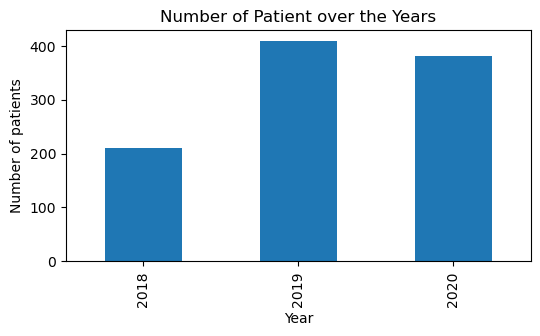

In [131]:
visit_counts_year = df_clean["Year"].value_counts().sort_index()
visit_counts_date = df_clean["Day of Week"].value_counts().sort_index()

fig1 = visit_counts_year.plot(
    kind='bar', 
    ylabel="Number of patients", 
    xlabel="Year", 
    title="Number of Patient over the Years", 
    figsize=(6, 3)
)
fig1

array([[<Axes: title={'center': 'Asthma'}, xlabel='Treatment', ylabel='Number of patients'>,
        <Axes: title={'center': 'Diabetes'}, xlabel='Treatment', ylabel='Number of patients'>,
        <Axes: title={'center': 'Heart Disease'}, xlabel='Treatment', ylabel='Number of patients'>,
        <Axes: title={'center': 'Hypertension'}, xlabel='Treatment', ylabel='Number of patients'>]],
      dtype=object)

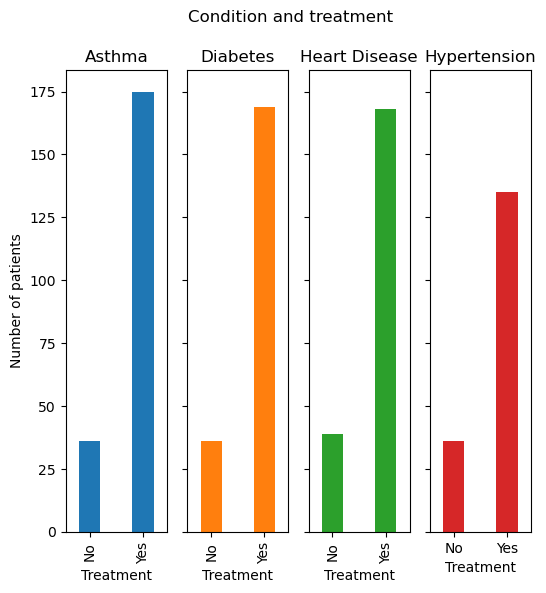

In [132]:
condition_n_treatment = df_clean.groupby(['Treatment', 'Condition']).size().unstack(fill_value=0)

fig2 = condition_n_treatment.plot(
    kind='bar', 
    subplots = True, 
    layout = (1,4), 
    sharex=True, 
    sharey=True, 
    legend=False, 
    title = "Condition and treatment", 
    ylabel="Number of patients", 
    figsize=(6, 6), 
    width=0.4, 
)
plt.xticks(rotation=0)
fig2

<Axes: title={'center': 'Condition and Visit by Year'}, xlabel='Year', ylabel='Number of patients'>

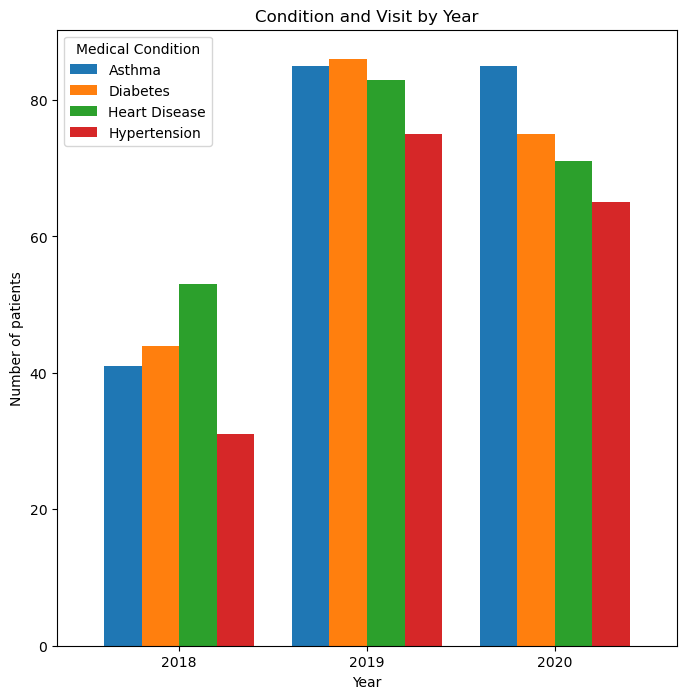

In [133]:
condition_per_year = df_clean.groupby(['Year', 'Condition']).size().unstack(fill_value=0)

fig3 = condition_per_year.plot(
    kind='bar', 
    title = "Condition and Visit by Year", 
    ylabel="Number of patients", 
    xlabel="Year", 
    figsize=(8, 8),
    width=0.8, 
)

bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']
plt.legend(title='Medical Condition', loc='upper left')
plt.xticks(rotation=0)

fig3

<Axes: title={'center': 'Number of Patients by Day-of-Week'}, xlabel='Month', ylabel='Number of patients'>

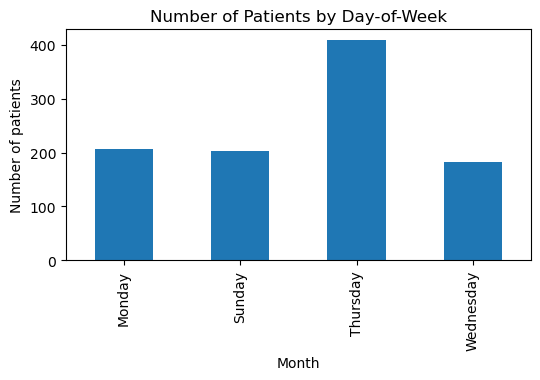

In [134]:
fig4 = visit_counts_date.plot(
    kind='bar', 
    ylabel="Number of patients", 
    xlabel="Month", 
    title="Number of Patients by Day-of-Week", 
    figsize=(6, 3)
)
fig4

# END - THANK YOU 